# DS-Wave 3D Testing


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # For Windows

import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.6.0+cu124
True


In [2]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import numpy as np

import plotly.graph_objects as go
import nbformat
print(nbformat.__version__)
print(nbformat.__file__)

module_path = Path("ds-wave.py").resolve()
if not module_path.exists():
	module_path = Path("python") / "ds-wave.py"
module_path = module_path.resolve()
spec = importlib.util.spec_from_file_location("ds_wave", module_path)
ds_wave = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ds_wave)

python_dir = Path("python").resolve()
if python_dir.exists() and str(python_dir) not in sys.path:
	sys.path.insert(0, str(python_dir))
import ds_wave_3D as ds_wave_3d

plt.rcParams["figure.dpi"] = 120


def make_low_bands(max_nu):
	return [
		(low, min(high, max_nu))
		for (low, high) in [(0.0, 0.5), (0.5, 0.6), (0.6, 0.67), (0.67, max_nu)]
		if min(high, max_nu) > low
	]


def describe_target(label, target):
	print(f"{label}: status={target.status}, m0={target.m0}")
	if target.success:
		print(f"{label} r range: 0 <= r <= {target.r[-1]:.6f}, samples={len(target.r)}")
	else:
		print(target.message)


def print_target_mode_summary(label, target, max_nu, n_points, bands):
	print(f"\n{label}")
	if not target.success:
		print(target.message)
		return None
	report = ds_wave.compute_target_mode_powers(
		target,
		n_points=n_points,
		nu_max=max_nu,
		mode_limit=0,
	)
	print_mode_report(report, bands)
	return report


def print_mode_report(report, bands=None, top_count=0):
	print(f"mode count: {report['mode_count']}")
	print(f"mean power:   {report['mean_power']:.10f}")
	print(f"median power: {report['median_power']:.10f}")
	print(f"max power:    {report['max_power']:.10f}")
	if bands is not None:
		for summary in ds_wave.summarise_mode_power_bands(report, bands):
			(lo, hi) = summary["range"]
			print(
				f"{lo:.3f} <= nu < {hi:.3f}: "
				f"count={summary['count']}, "
				f"mean={summary['mean_power']:.10f}, "
				f"median={summary['median_power']:.10f}, "
				f"max={summary['max_power']:.10f}"
			)
	if top_count > 0:
		print("Top low-frequency modes:")
		for (mode, radius, power) in zip(report["modes"][:top_count], report["radii"][:top_count], report["powers"][:top_count]):
			print(f"k={mode.astype(int)}, nu={radius:.6f}, power={power:.6f}")


def print_point_mode_summary(label, point_set, max_nu, bands=None, mode_limit=0, top_count=0):
	print(f"\n{label}")
	report = ds_wave.compute_low_frequency_mode_powers(
		point_set,
		nu_max=max_nu,
		mode_limit=mode_limit,
	)
	print_mode_report(report, bands=bands, top_count=top_count)
	return report


def set_active_points(point_set, label):
	global points, active_points_label
	points = point_set
	active_points_label = label
	print(f"Active point set: {active_points_label}")

5.10.4
c:\Users\admin\miniconda3\envs\bluenoise_pointprocesses\lib\site-packages\nbformat\__init__.py


In [3]:
# Easy-to-edit parameters
nu0 = 0.85
#nu0 = 0.70
e0 = 0.0
nu_max = 5.0
n_nu = 1001
n_r = 128

# while traveling, use fewer points cause laptop is shit
n_points = 1024
iterations = 500
seed = 1234
m0_values = [1.0, 2.0, "min"]
device = "auto"

# PCF matching is the only synthesis algorithm: the faithful Heck-2013 / DS-Wave
# RDF-matching optimizer that produces the decaying-square-wave radial PSD.
step_scale = 1.0
num_bins = None  # None resolves to max(4096, n_points): RDF bins decoupled from N
smoothing = None
chunk_size = 256
initial_points = None

# Effective PCF resolution implied by the (None, None) defaults above.
from ds_wave_targetrdf import resolve_targetrdf_resolution
(resolved_num_bins, resolved_smoothing) = resolve_targetrdf_resolution(n_points, num_bins, smoothing)
print(f"resolved PCF resolution: nbins={resolved_num_bins}, smoothing={resolved_smoothing:.2f} bins")

# Extra tests
sweep_iterations = min(iterations, 1000)
sweep_include_full_domain_target = True
sweep_smoothing_values = [0.5 * resolved_smoothing, resolved_smoothing, 1.5 * resolved_smoothing]
sweep_num_bins_values = [128, 256, 512]
sweep_step_scale_values = [0.5 * step_scale, step_scale, 1.5 * step_scale]

n_points_3d = 4096
iterations_3d = 5 * iterations
num_bins_3d = None  # None resolves to max(4096, n_points): RDF bins decoupled from N (RC-1 fix, 3D)
smoothing_3d = None  # None holds the calibrated normalized sigma_rnorm=0.04 via the N^(1/3) normalizer
step_scale_3d = step_scale
chunk_size_3d = chunk_size


resolved PCF resolution: nbins=4096, smoothing=10.24 bins


3D m0=1.34375: optimal - Optimization terminated successfully. (HiGHS Status 7: Optimal)


C:\Users\admin\AppData\Local\Temp\ipykernel_6140\2767334434.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


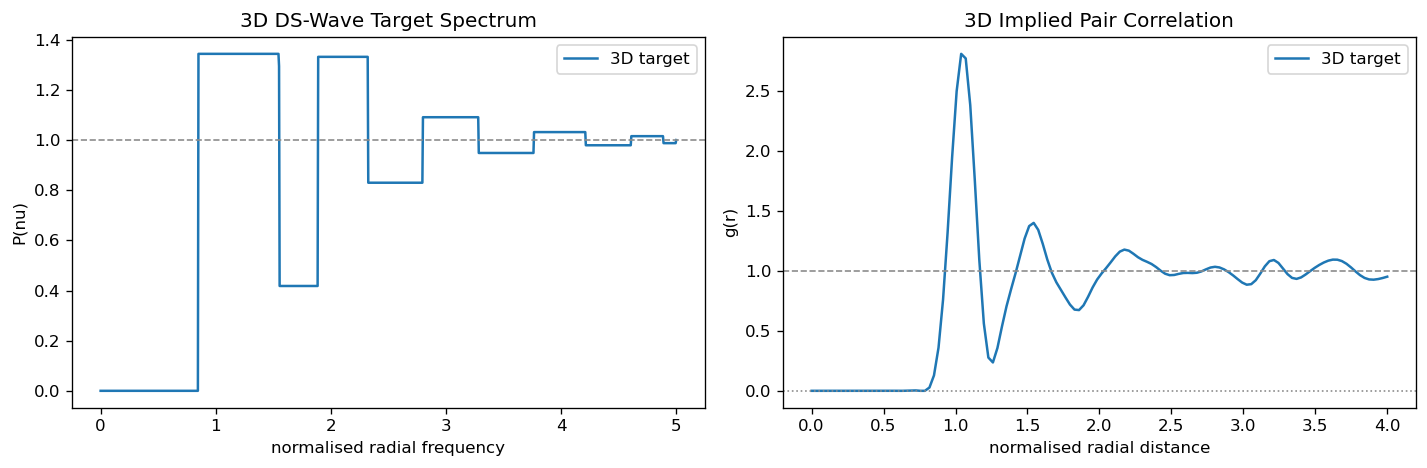

In [4]:
# 3D DS-Wave target exploration
# This solves/plots the optimized 3D target spectrum and implied g(r).

target_3d = ds_wave_3d.solve_ds_wave_target_3d(
	nu0=nu0,
	e0=e0,
	m0="min",
	nu_max=nu_max,
	n_nu=n_nu,
	n_r=n_r,
	require_success=False,
)
print(f"3D m0={target_3d.m0}: {target_3d.status} - {target_3d.message}")
if not target_3d.success:
	raise RuntimeError(target_3d.message)

fig = ds_wave_3d.plot_3d_target(target_3d)
fig.show()

3D points: (4096, 3), device=cuda
Energy history:
0.19742581
0.008572191
0.0075658415
0.0072545344
0.0071611777
0.0071504666
0.007149765
0.007149765
0.007149765
0.007149765
0.007149765


C:\Users\admin\AppData\Local\Temp\ipykernel_6140\241240304.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\admin\AppData\Local\Temp\ipykernel_6140\241240304.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


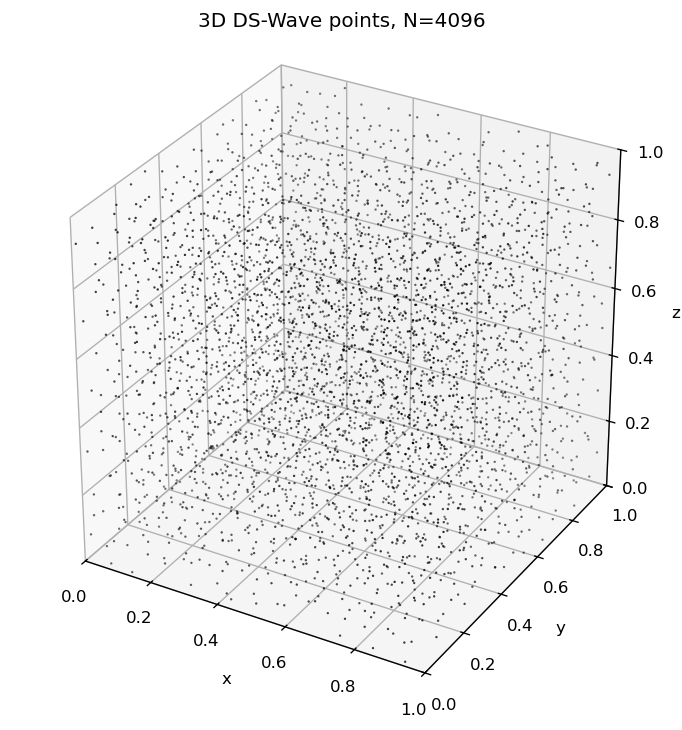

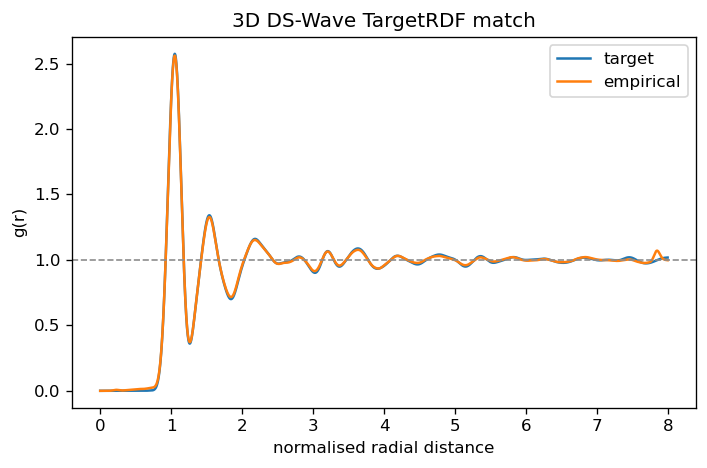

In [5]:
# 3D DS-Wave point synthesis.
synthesis_3d = ds_wave_3d.synthesize_toroidal_points_3d(
	target_3d,
	n_points=n_points_3d,
	iterations=iterations_3d,
	seed=seed,
	device=device,
	step_scale=step_scale_3d,
	nbins=num_bins_3d,
	smoothing=smoothing_3d,
	chunk_size=chunk_size_3d,
	log_every=max(iterations_3d // 10, 1),
)
points_3d = synthesis_3d.points
print(f"3D points: {points_3d.shape}, device={synthesis_3d.device}")
print("Energy history:")
for value in synthesis_3d.energy_history:
	print(value)

fig = plt.figure(figsize=(6, 6), dpi=120)
ax = fig.add_subplot(111, projection="3d")
ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], s=2.0, c="black", linewidths=0)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_zlim(0, 1)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title(f"3D DS-Wave points, N={n_points_3d}")
try:
	ax.set_box_aspect((1, 1, 1))
except AttributeError:
	pass
fig.tight_layout()
fig.show()

(fig, ax) = plt.subplots(figsize=(6, 4), dpi=120)
ax.plot(synthesis_3d.r_values, synthesis_3d.target_rdf, label="target")
ax.plot(synthesis_3d.r_values, synthesis_3d.final_rdf, label="empirical")
ax.axhline(1.0, color="0.55", linestyle="--", linewidth=1)
ax.set_xlabel("normalised radial distance")
ax.set_ylabel("g(r)")
ax.set_title("3D DS-Wave TargetRDF match")
ax.legend()
fig.tight_layout()
fig.show()

In [6]:
if "points_3d" not in globals():
	print("Run the 3D point synthesis cell first.")
else:
	fig = go.Figure(
		data=[
			go.Scatter3d(
				x=points_3d[:, 0],
				y=points_3d[:, 1],
				z=points_3d[:, 2],
				mode="markers",
				marker=dict(
					size=2,
					color="black",
					opacity=0.75,
				),
			)
		]
	)

	fig.update_layout(
		title=f"3D DS-Wave points, N={n_points_3d}",
		scene=dict(
			xaxis=dict(range=[0, 1], title="x"),
			yaxis=dict(range=[0, 1], title="y"),
			zaxis=dict(range=[0, 1], title="z"),
			aspectmode="cube",
		),
		width=750,
		height=750,
	)

	fig.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_6140\337161806.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


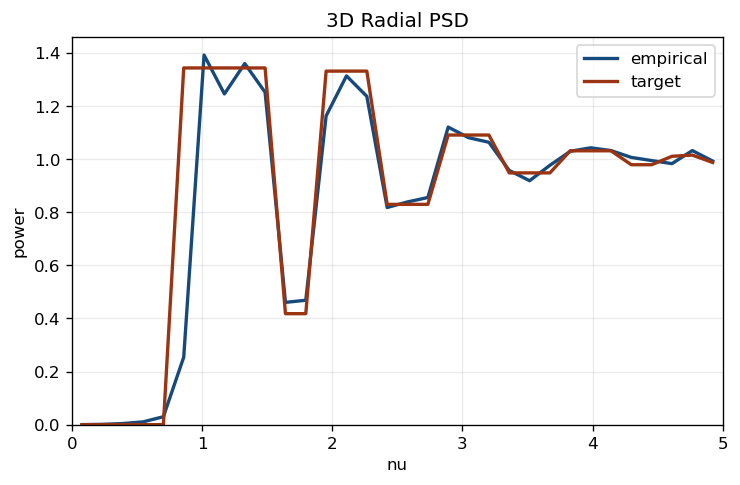

In [7]:
# 3D radial PSD diagnostic
psd_num_bins_3d = 32
psd_mode_limit_3d = 64000

if "points_3d" not in globals():
	print("Run the 3D point synthesis cell first.")
else:
	fig = ds_wave_3d.plot_radial_psd_overlay_3d(
		points_3d,
		target_3d,
		num_bins=psd_num_bins_3d,
		max_freq=nu_max,
		mode_limit=psd_mode_limit_3d,
	)
	fig.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_6140\2810252464.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


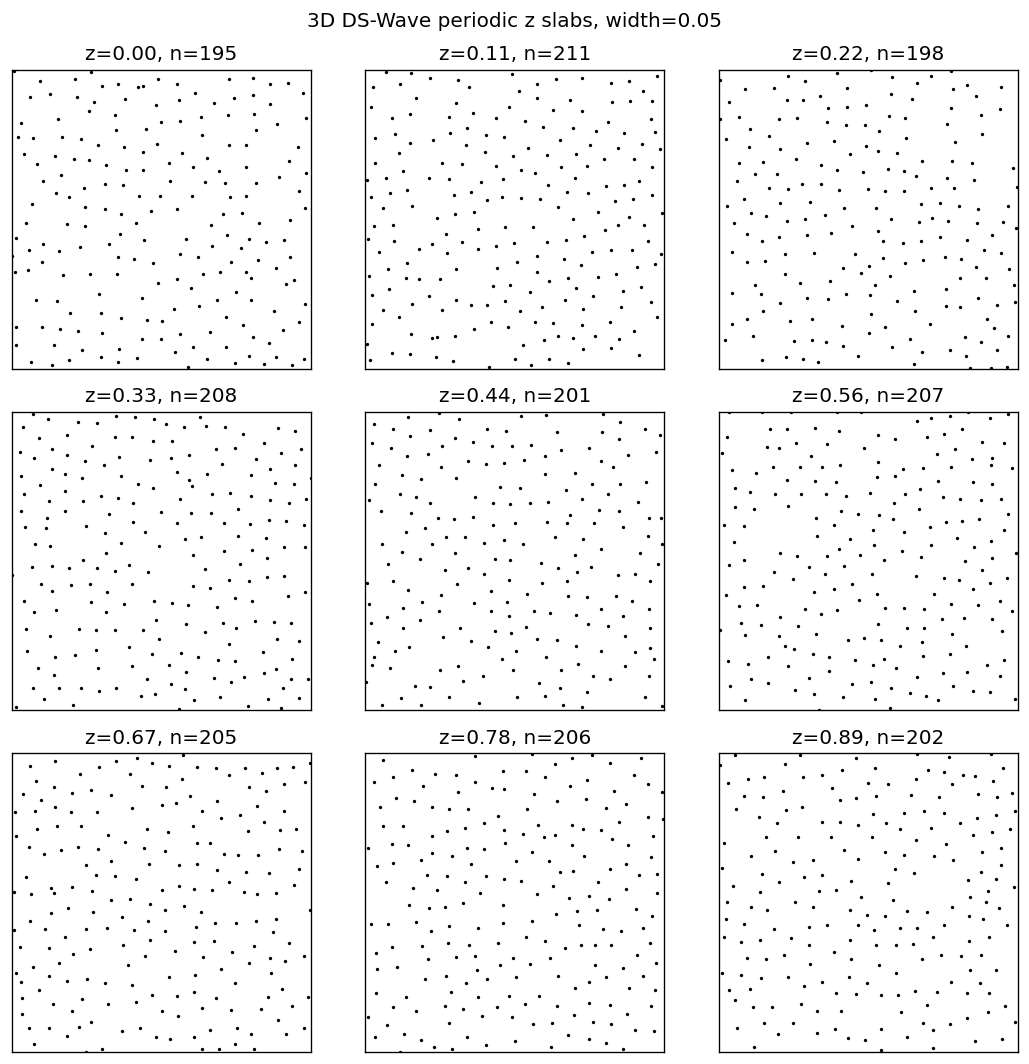

In [8]:
# 3D slice visualization: several periodic z slabs
slice_width = 0.05
slice_z_values = np.linspace(0.0, 1.0, 9, endpoint=False)

if "points_3d" not in globals():
	print("Run the 3D point synthesis cell first.")
else:
	fig, axes = plt.subplots(3, 3, figsize=(9, 9), dpi=120)
	for ax, z0 in zip(axes.ravel(), slice_z_values):
		dz = np.abs(points_3d[:, 2] - z0)
		dz = np.minimum(dz, 1.0 - dz)
		slice_points = points_3d[dz < 0.5 * slice_width]

		ax.scatter(slice_points[:, 0], slice_points[:, 1], s=4, c="black", linewidths=0)
		ax.set_xlim(0, 1)
		ax.set_ylim(0, 1)
		ax.set_aspect("equal")
		ax.set_xticks([])
		ax.set_yticks([])
		ax.set_title(f"z={z0:.2f}, n={len(slice_points)}")

	fig.suptitle(f"3D DS-Wave periodic z slabs, width={slice_width}")
	fig.tight_layout()
	fig.show()


slice points: 200 / 4096


C:\Users\admin\AppData\Local\Temp\ipykernel_6140\1425157432.py:68: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


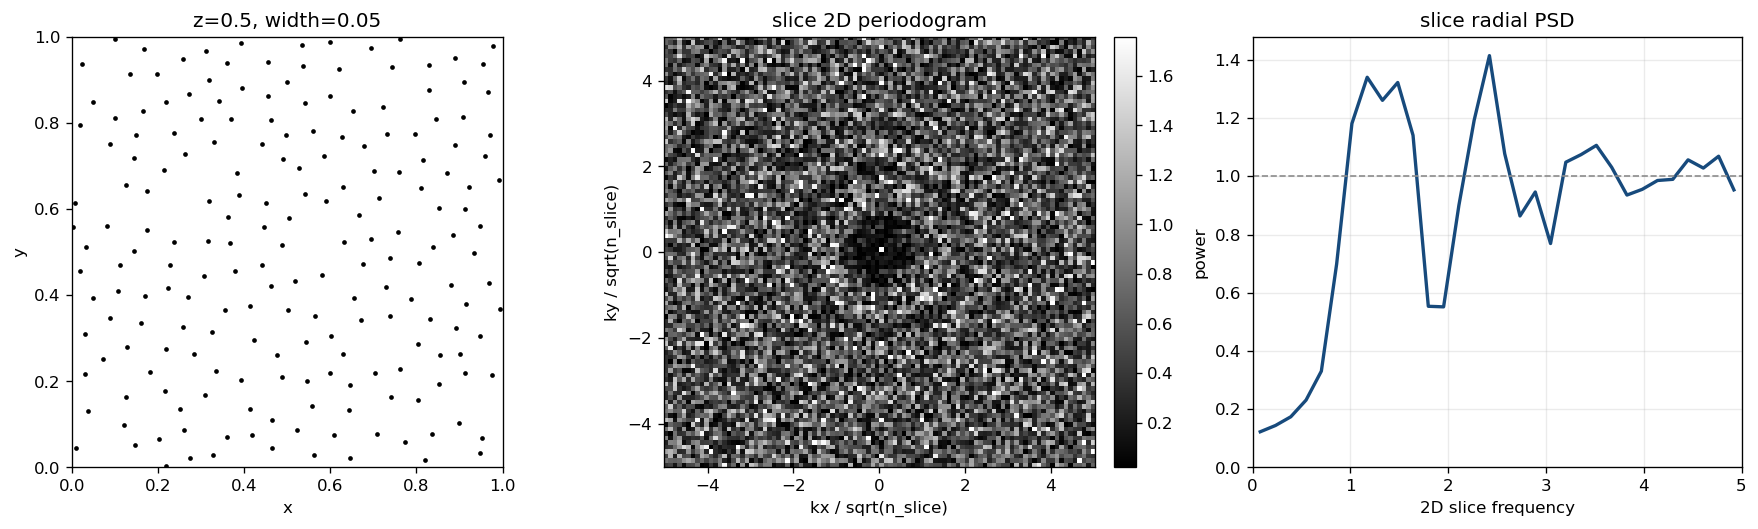

In [9]:
if "points_3d" not in globals():
	print("Run the 3D point synthesis cell first.")
else:
	# Single 3D slice diagnostic with 2D periodogram and radial PSD
	slice_z = 0.5
	slice_width = 0.05
	slice_psd_grid_size = 96
	slice_num_bins = 32
	slice_max_freq = 5.0

	slice_dz = np.abs(points_3d[:, 2] - slice_z)
	slice_dz = np.minimum(slice_dz, 1.0 - slice_dz)
	slice_points = points_3d[slice_dz < 0.5 * slice_width][:, :2]
	print(f"slice points: {slice_points.shape[0]} / {points_3d.shape[0]}")

	fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=120)
	axes[0].scatter(slice_points[:, 0], slice_points[:, 1], s=8, c="black", linewidths=0)
	axes[0].set_xlim(0, 1)
	axes[0].set_ylim(0, 1)
	axes[0].set_aspect("equal")
	axes[0].set_title(f"z={slice_z}, width={slice_width}")
	axes[0].set_xlabel("x")
	axes[0].set_ylabel("y")

	if slice_points.shape[0] >= 2:
		power_2d, extent = ds_wave.compute_periodogram_2d(
			slice_points,
			grid_size=slice_psd_grid_size,
			max_freq=slice_max_freq,
		)
		display_power = power_2d.copy()
		display_power[display_power.shape[0] // 2, display_power.shape[1] // 2] = np.nan
		log_power = np.log1p(display_power)
		vmin, vmax = np.nanpercentile(log_power, [2.0, 99.0])
		image = axes[1].imshow(
			log_power,
			origin="lower",
			extent=extent,
			cmap="gray",
			vmin=vmin,
			vmax=vmax,
			interpolation="nearest",
		)
		axes[1].set_title("slice 2D periodogram")
		axes[1].set_xlabel("kx / sqrt(n_slice)")
		axes[1].set_ylabel("ky / sqrt(n_slice)")
		fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)

		freqs, radial = ds_wave.compute_radial_psd(
			slice_points,
			num_bins=slice_num_bins,
			max_freq=slice_max_freq,
			mode_limit=0,
		)
		axes[2].plot(freqs, radial, color="#174a7c", linewidth=2.0)
		axes[2].axhline(1.0, color="0.55", linestyle="--", linewidth=1)
		axes[2].set_xlim(0.0, slice_max_freq)
		axes[2].set_ylim(bottom=0.0)
		axes[2].set_title("slice radial PSD")
		axes[2].set_xlabel("2D slice frequency")
		axes[2].set_ylabel("power")
		axes[2].grid(True, alpha=0.25)
	else:
		axes[1].set_axis_off()
		axes[2].set_axis_off()

	fig.tight_layout()
	fig.show()
